In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler : 정규화 일 경우 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"/Users/kdt_0900_lyn/data_analysis/resource/dataset"
file_name = r"titanic.csv"
file_path = os.path.join(base_path, file_name)

In [3]:
df = pd.read_csv(file_path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [4]:
drop_columns =  ["PassengerId", "Name", "Ticket", "Cabin", "Embarked"]
titanic_df = df.drop(drop_columns, axis=1)

In [5]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## 1단계 데이터 전처리

In [6]:
# 수치형 : Age, SibSp, Parch, Fare
# 분류형 : Survived, Pclass, Sex
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [7]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


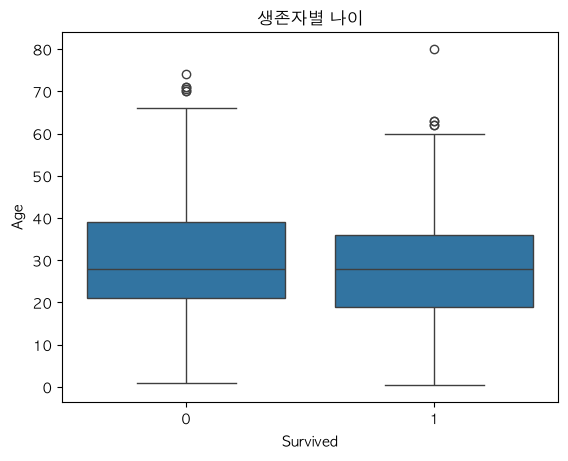

In [8]:
sns.boxplot(titanic_df, x="Survived" , y="Age")
plt.title("생존자별 나이")
plt.show()

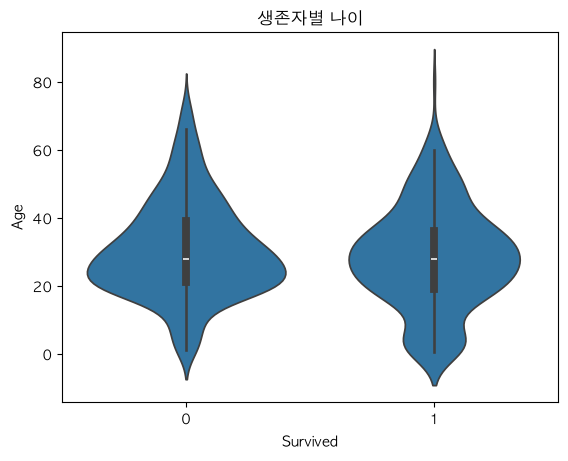

In [9]:
sns.violinplot(titanic_df, x="Survived" , y="Age")
plt.title("생존자별 나이")
plt.show()

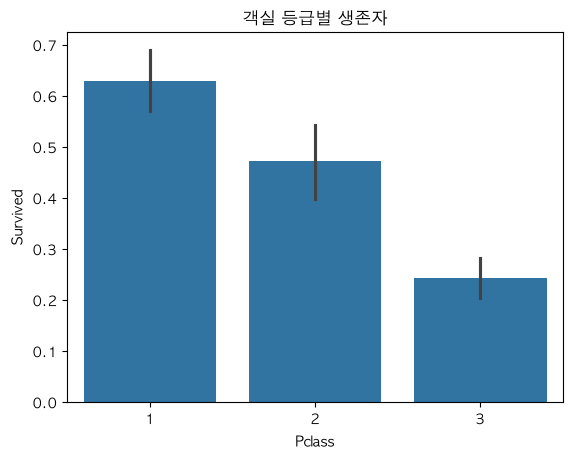

In [10]:
sns.barplot(titanic_df, x="Pclass" , y="Survived")
plt.title("객실 등급별 생존자")
plt.show()

In [11]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())

In [12]:
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


## 원 핫 인코딩 (one-Hot-encoding)
- 글자나 범주형(분류형 ) 데이터를 컴퓨터가 좋아하는 0 과 1의 행렬구조로 변환하는 전처리 기술입니다 

In [13]:
# pd.get_dummies?

titanic_df["Sex"].map(lambda gender: {"male":0, "female": 1}[gender])
titanic_df["Sex"].map({"male":0, "female": 1})

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64

In [16]:
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22,1,0,7.2500
1,1,1,female,38,1,0,71.2833
2,1,3,female,26,0,0,7.9250


### 파생 변수 

In [17]:
titanic_df["FmilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FmilySize
0,0,3,male,22,1,0,7.2500,2
1,1,1,female,38,1,0,71.2833,2
2,1,3,female,26,0,0,7.9250,1


### 상관관계 분석 및 다중공선성

In [20]:
corr_mrtrix = titanic_df.corr(numeric_only=True)
corr_mrtrix

,Survived,Pclass,Age,SibSp,Parch,Fare,FmilySize
Survived,1.000000,-0.338481,-0.064909,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.339999,0.083081,0.018443,-0.549500,0.065997
Age,-0.064909,-0.339999,1.000000,-0.233066,-0.172745,0.096838,-0.245593
SibSp,-0.035322,0.083081,-0.233066,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,-0.172745,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.096838,0.159651,0.216225,1.000000,0.217138
FmilySize,0.016639,0.065997,-0.245593,0.890712,0.783111,0.217138,1.000000


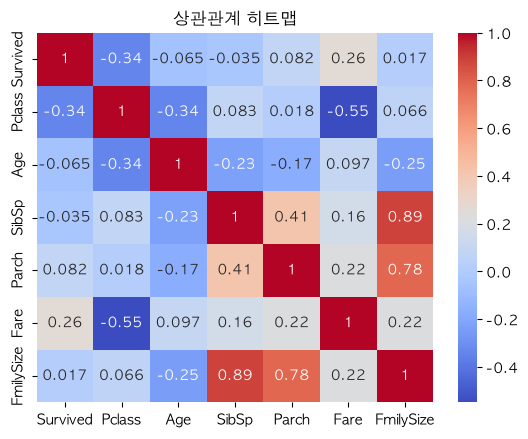

In [24]:
sns.heatmap(corr_mrtrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")
plt.show()

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
X = titanic_df.drop("Survived", axis=1)
X.head(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,FmilySize
0,3,male,22,1,0,7.2500,2
1,1,female,38,1,0,71.2833,2
2,3,female,26,0,0,7.9250,1


In [27]:
y = titanic_df["Survived"]
y.head(3)

0    0
1    1
2    1
Name: Survived, dtype: int64

In [28]:
X.shape

(891, 7)

In [36]:
vif = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])]
print(X.columns)
vif


ValueError: could not convert string to float: 'male'

### VIF
- 한 독립 변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지 설명하는 값을 의미한다
  증, 족립변수와 ㄷ독립변수 관계를 의미하며
### VIF 해석 
- VIF < 5 : 문제 없음
- 5 <= VIF <= 10: 주의
- VIF > 10 : 다중 공정성 의심 (조치 , 삭제, 고려 )

In [46]:
titanic_df = titanic_df.drop(["SibSp", "Parch"], axis=1)


KeyError: "['SibSp', 'Parch'] not found in axis"

In [ ]:
y = titanic_df["Survived"]
y.head()

In [ ]:
vif = [variance_inflation_factor(X.values, i) for i in range (X.shape[1])]
print(X.columns)
vif

In [ ]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2 random_state=2026, strratify=y )
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

In [ ]:
X.describe

In [ ]:
# 정규화하는 경우  ->0최소,1최대 로 나열함
# 표준화 

In [ ]:
# 표준화 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform()
X_test_scaled = scaler.transform(X_test)

## 2단계 , 모델 준비 

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
lr = LogisticRegression()

## 3단계, 모델 학습 

In [ ]:
lr.fit(X_train_scaled, y_train)

## 4단계 모델 평가 

In [ ]:
train_score - lr.score(X_train_scaled, y_train)
test_score - lr.scor(eX_train_scaled, y_test)

print(f"훈련 데이터 정확도 점수: {train_score:.2f}")
print(f"테스트 데이터 정확도 점수: {test_score:.2f}")

### 시그모이드 함수 (Sigmoid Function)
수학자들이 만든 특수한 함수로, 여기에 어떤 숫자를 넣든 무조건 **0과 1 사이의 소수점(확률)**으로 꽉 눌러서 변환해 줍니다.

$$\text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fsib2q%2FbtsDJkfaBMy%2FAAAAAAAAAAAAAAAAAAAAAJwQd20TZhIxLx58GiUJdYxCLH_4xkSt66vEea-TnEkx%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZyqh5kd4SOqkuF96VWHHU3%252B91F0%253D)

In [ ]:
# 시그모이드 함수 지나간 값
y_pred = lr.predict(X_test_scaled)
y_pred

In [ ]:
lr.predict_proba(X_test_scaled)

In [ ]:
print(f"모델의 예측 확률: {lr.predict_proba(X_test_scaled)[:5]}")


In [ ]:
print(f"테스트 정확도 : {accuracy_score(y_pred, y_test)}")

### 꺷-쳑ㅍㄷ
- 이진 분류 모델의 성능을 임계값을 기준에서 시각적으로 평가한 그래프입니다
- X축(특이도) : TPR: 실제 양성 중 모델이 양성으로 맞춘 비율
- y축(민감도) : TPR: 실제 음성 중 모델이 양성으로 잘못 맞춘 비율

In [ ]:
from sklearn.metrics import RocCurveDisplay

In [ ]:
RocCurveDisplay.from_estimeator(lr, X_test_scaled, y_test)

In [ ]:
# 각 가중치
lr_coef[0]

In [ ]:
coef_df = pd,DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_value(by="Coef", ascending=False)

coef_df

In [ ]:
sns.barplot(coef_df, x="")

In [ ]:
wrong_cases = X_ 